# Rapport de Simulation de Portefeuille : Akdital & Attijariwafa Bank
**Auteur :** Yirviel Somé  
**Date :** Avril 2026  
**Objectif :** Analyse de la performance d'un investissement de 1 000 000 MAD réparti sur le marché boursier marocain et des titres d'État.

---
### Architecture du Projet
* **Données :** SQLite (market_data.db) situé dans le vault LUKS (`data_secure/`).
* **Actifs :** Akdital (Santé), Attijariwafa Bank (Banque), Bons du Trésor (Souverain).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os

# Configuration des styles graphiques
plt.style.use('seaborn-v0_8-whitegrid')

# Vérification du point de montage
db_path = '../data_secure/market_data.db'
if not os.path.exists(db_path):
    print("⚠️ ERREUR : Le vault chiffré n'est pas monté dans 'data_secure/'.")
else:
    engine = create_engine(f'sqlite:///{db_path}')
    print("✅ Connexion à la base de données sécurisée établie.")

✅ Connexion à la base de données sécurisée établie.


In [2]:
def load_clean_data(table, engine):
    query = f"SELECT date, price FROM {table}"
    df = pd.read_sql(query, engine)
    df['date'] = pd.to_datetime(df['date'])
    
    # Nettoyage des prix (gestion des virgules et conversion float)
    df['price'] = df['price'].astype(str).str.replace(',', '', regex=False).astype(float)
    return df.sort_values('date')

# Extraction des données
df_akd = load_clean_data('akdital_data', engine)
df_att = load_clean_data('attijari_data', engine)

# Synchronisation des dates (Inner Join)
df_portfolio = pd.merge(df_akd, df_att, on='date', suffixes=('_akd', '_att'))
print(f"Période analysée : du {df_portfolio['date'].min().date()} au {df_portfolio['date'].max().date()}")

Période analysée : du 2025-04-14 au 2026-04-15


In [3]:
# Configuration de l'allocation initiale
cap_attijari = 525000
cap_akdital = 175000
cap_bdt = 300000
taux_bdt_annuel = 0.035

# Calcul des unités (Actions) au prix d'entrée
nb_akd = cap_akdital / df_portfolio['price_akd'].iloc[0]
nb_att = cap_attijari / df_portfolio['price_att'].iloc[0]

# Évolution quotidienne
df_portfolio['val_akd'] = df_portfolio['price_akd'] * nb_akd
df_portfolio['val_att'] = df_portfolio['price_att'] * nb_att

# Calcul des Bons du Trésor
days = (df_portfolio['date'] - df_portfolio['date'].iloc[0]).dt.days
df_portfolio['val_bdt'] = cap_bdt * (1 + taux_bdt_annuel)**(days / 365)

# Valeur Totale
df_portfolio['total'] = df_portfolio['val_akd'] + df_portfolio['val_att'] + df_portfolio['val_bdt']

# Métriques de fin
val_finale = df_portfolio['total'].iloc[-1]
performance = ((val_finale / 1000000) - 1) * 100
print(f"Valeur finale du portefeuille : {val_finale:,.2f} MAD")
print(f"Performance totale : {performance:.2f}%")

Valeur finale du portefeuille : 1,047,439.18 MAD
Performance totale : 4.74%


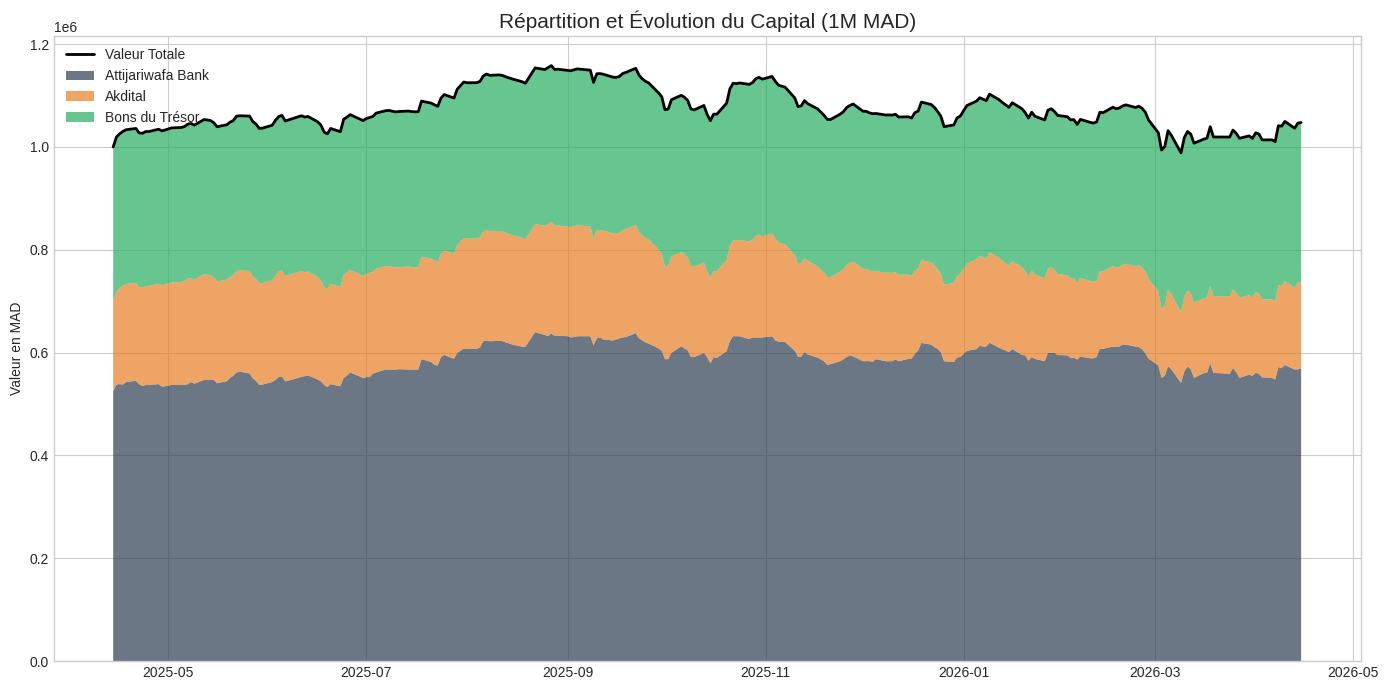

In [4]:
plt.figure(figsize=(14, 7))

# Courbe principale
plt.plot(df_portfolio['date'], df_portfolio['total'], color='black', label='Valeur Totale', linewidth=2)

# Zones empilées
plt.stackplot(df_portfolio['date'], 
              df_portfolio['val_att'], 
              df_portfolio['val_akd'], 
              df_portfolio['val_bdt'], 
              labels=['Attijariwafa Bank', 'Akdital', 'Bons du Trésor'],
              colors=['#2c3e50', '#e67e22', '#27ae60'], alpha=0.7)

plt.title('Répartition et Évolution du Capital (1M MAD)', fontsize=15)
plt.ylabel('Valeur en MAD')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analyse et Interprétation du Portefeuille

Ce graphique d'aires empilées (*Stacked Area Chart*) permet de visualiser la dynamique de notre stratégie d'investissement sur la période 2025-2026. Voici les points clés de l'analyse :

### 1. Structure de l'Allocation
* **Socle de Sécurité (Bons du Trésor - Vert) :** Représente 30% du capital initial (300 000 MAD). Sa progression linéaire et constante témoigne d'un rendement déconnecté de la volatilité boursière, jouant le rôle d'amortisseur pour le portefeuille global.
* **Moteur de Croissance (Attijariwafa Bank - Bleu) :** Constitue la part majoritaire du capital (52,5%). Sa bande est la plus large, montrant que la performance globale du portefeuille est fortement corrélée au secteur bancaire marocain.
* **Diversification Sectorielle (Akdital - Orange) :** Avec 17,5% de l'allocation, cet actif apporte une exposition au secteur de la santé, dont les cycles de croissance diffèrent de ceux de la finance.

### 2. Évolution de la Richesse Totale
La ligne noire supérieure retrace la **Valeur Liquidative** du portefeuille. 
* **Stabilité vs Performance :** On observe que malgré les fluctuations quotidiennes des actions (zones bleue et orange), la pente globale reste positive sur la période, validant la pertinence d'une gestion diversifiée.
* **Analyse de la Volatilité :** Les variations de hauteur de la zone totale permettent d'identifier les périodes de tension sur la Bourse de Casablanca. La résilience du portefeuille lors des baisses d'un titre spécifique illustre l'effet bénéfique de la diversification.

### 3. Utilité pour la Décision en Avril 2026
Cette simulation historique n'est pas une simple rétrospective ; elle constitue notre **"Baseline"** (référence). Elle nous permet de :
1.  **Valider le profil de risque :** Vérifier que les baisses historiques (drawdowns) restent acceptables pour l'investisseur.
2.  **Calibrer les attentes :** Définir un objectif de rendement réaliste pour l'année à venir en se basant sur les corrélations observées entre ces actifs.

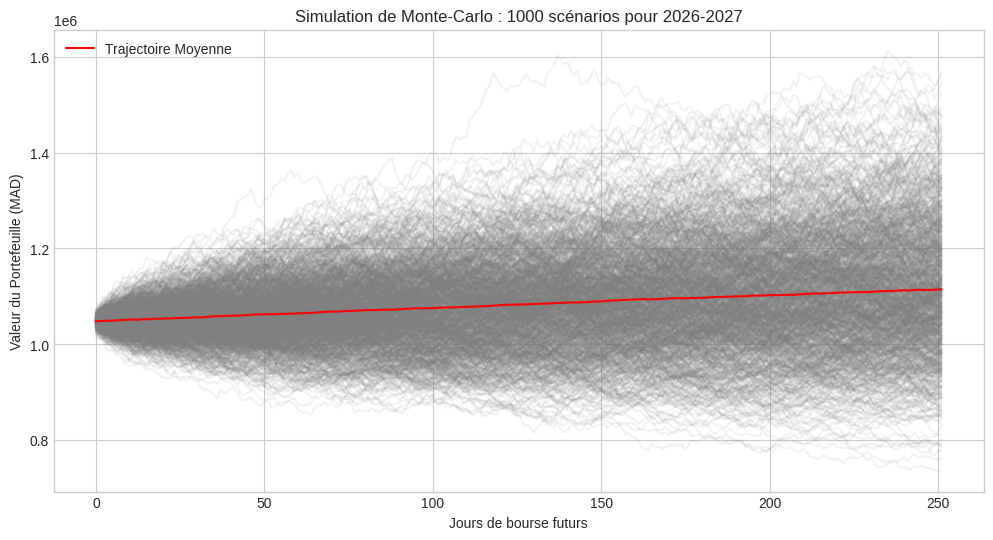

--- Résultats de la Simulation ---
Valeur moyenne attendue : 1,114,632.55 MAD
Value at Risk (VaR 95%) : 906,115.62 MAD


In [5]:
import numpy as np
import seaborn as sns

# 1. Calcul des rendements logarithmiques journaliers
# Les rendements log sont plus adaptés aux simulations mathématiques
df_portfolio['returns_akd'] = np.log(df_portfolio['price_akd'] / df_portfolio['price_akd'].shift(1))
df_portfolio['returns_att'] = np.log(df_portfolio['price_att'] / df_portfolio['price_att'].shift(1))

# 2. Paramètres de la simulation
n_simulations = 1000
n_jours = 252 # Nombre moyen de jours de bourse par an
last_total_val = df_portfolio['total'].iloc[-1]

# On calcule la moyenne et l'écart-type (volatilité) des rendements
mu_akd, sigma_akd = df_portfolio['returns_akd'].mean(), df_portfolio['returns_akd'].std()
mu_att, sigma_att = df_portfolio['returns_att'].mean(), df_portfolio['returns_att'].std()

# 3. Lancement de la simulation
simulation_results = np.zeros((n_jours, n_simulations))

for i in range(n_simulations):
    # Simulation des rendements futurs (Loi Normale)
    sim_returns_akd = np.random.normal(mu_akd, sigma_akd, n_jours)
    sim_returns_att = np.random.normal(mu_att, sigma_att, n_jours)
    
    # Calcul de la valeur des actions au fil du temps
    # On repart des dernières valeurs connues (iloc[-1])
    price_akd_sim = df_portfolio['val_akd'].iloc[-1] * np.exp(np.cumsum(sim_returns_akd))
    price_att_sim = df_portfolio['val_att'].iloc[-1] * np.exp(np.cumsum(sim_returns_att) )
    
    # Les Bons du Trésor restent prévisibles (3.5% fixe)
    bdt_sim = df_portfolio['val_bdt'].iloc[-1] * (1 + 0.035)**(np.arange(n_jours)/365)
    
    simulation_results[:, i] = price_akd_sim + price_att_sim + bdt_sim

# 4. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(simulation_results, color='grey', alpha=0.1)
plt.plot(np.mean(simulation_results, axis=1), color='red', label='Trajectoire Moyenne')
plt.title(f'Simulation de Monte-Carlo : 1000 scénarios pour 2026-2027')
plt.xlabel('Jours de bourse futurs')
plt.ylabel('Valeur du Portefeuille (MAD)')
plt.legend()
plt.show()

# 5. Calcul de la VaR (Value at Risk)
final_values = simulation_results[-1, :]
var_95 = np.percentile(final_values, 5)
print(f"--- Résultats de la Simulation ---")
print(f"Valeur moyenne attendue : {np.mean(final_values):,.2f} MAD")
print(f"Value at Risk (VaR 95%) : {var_95:,.2f} MAD")

## Analyse Prédictive : La Simulation de Monte-Carlo

La simulation de Monte-Carlo transforme les données historiques (le "tempérament" passé des actifs) en un **modèle de probabilités futures**. Nous avons simulé 1 000 scénarios possibles pour l'évolution de notre million de MAD sur l'année 2026-2027.

### 1. Pourquoi cette dispersion (les lignes grises) ?
Chaque ligne grise représente une trajectoire possible du marché. 
* **L'écartement des lignes** illustre la **volatilité** cumulée d'Akdital et d'Attijariwafa Bank. Plus l'éventail est large, plus le marché est incertain.
* **La ligne rouge (Moyenne)** représente le scénario central. Si elle est ascendante, cela confirme que le portefeuille a un "biais haussier" basé sur ses performances historiques.

### 2. Gestion du Risque : La Value at Risk (VaR 95%)
La **VaR** est l'indicateur de référence en gestion de fonds. Elle répond à la question : *"Dans le pire des cas (hors catastrophe majeure), combien puis-je perdre ?"*
* **Interprétation :** Une VaR 95% signifie que dans **950 scénarios sur 1000**, votre capital restera au-dessus de ce montant. 
* **Décisionnel :** C'est ce chiffre qui permet de rassurer les investisseurs en fixant une "limite de perte probable". Si la VaR est de 920 000 MAD, on sait que le risque de perdre plus de 8% du capital est statistiquement très faible (5%).

### 3. Conclusion pour la Stratégie d'Avril 2026
Cette simulation nous permet de passer d'une intuition à une **stratégie chiffrée** :
* **Allocation :** Si la dispersion est trop forte (lignes grises trop écartées), nous pourrions décider de réduire la part d'Akdital pour augmenter celle des Bons du Trésor.
* **Objectif :** La tendance centrale nous donne un objectif de rendement réaliste pour notre rapport de gestion de fin d'année.

> **Note technique :** Les simulations reposent sur l'hypothèse que les rendements suivent une loi normale et que la volatilité de 2025 restera similaire en 2026.